In [28]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("datatattle/covid-19-nlp-text-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'covid-19-nlp-text-classification' dataset.
Path to dataset files: /kaggle/input/covid-19-nlp-text-classification


### Inspecting the Dataset Files

Before we can use the dataset for training, let's look at the files that were downloaded from Kaggle to understand their structure and identify the relevant data files (e.g., CSV, JSON).

In [29]:
import os

# The 'path' variable was defined in the previous cell
print(f"Listing files in: {path}")
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

Listing files in: /kaggle/input/covid-19-nlp-text-classification
/kaggle/input/covid-19-nlp-text-classification/Corona_NLP_test.csv
/kaggle/input/covid-19-nlp-text-classification/Corona_NLP_train.csv


### Load and Inspect the Datasets

Now that we know the paths to the CSV files, let's load them into pandas DataFrames and inspect their structure. We'll start with the training dataset (`Corona_NLP_train.csv`) to understand its columns, data types, and a few sample rows.

In [30]:
import pandas as pd

# Construct full paths to the CSV files
train_csv_path = os.path.join(path, 'Corona_NLP_train.csv')
test_csv_path = os.path.join(path, 'Corona_NLP_test.csv')

# Load the training dataset
train_df = pd.read_csv(train_csv_path, encoding='latin-1')

print("Train DataFrame Head:")
print(train_df.head())

print("\nTrain DataFrame Info:")
train_df.info()

Train DataFrame Head:
   UserName  ScreenName   Location     TweetAt  \
0      3799       48751     London  16-03-2020   
1      3800       48752         UK  16-03-2020   
2      3801       48753  Vagabonds  16-03-2020   
3      3802       48754        NaN  16-03-2020   
4      3803       48755        NaN  16-03-2020   

                                       OriginalTweet           Sentiment  
0  @MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...             Neutral  
1  advice Talk to your neighbours family to excha...            Positive  
2  Coronavirus Australia: Woolworths to give elde...            Positive  
3  My food stock is not the only one which is emp...            Positive  
4  Me, ready to go at supermarket during the #COV...  Extremely Negative  

Train DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41157 entries, 0 to 41156
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UserN

### Data Preprocessing

Before feeding the data into the RNN model, we need to perform several preprocessing steps:

1.  **Handle Missing Values:** Address any missing data in the `OriginalTweet` or `Sentiment` columns.
2.  **Text Cleaning:** Remove noise from the tweets (e.g., URLs, mentions, special characters, convert to lowercase).
3.  **Tokenization:** Convert text into numerical sequences using a tokenizer.
4.  **Padding/Truncating Sequences:** Ensure all input sequences have a uniform length.
5.  **Label Encoding:** Convert sentiment labels into numerical format.
6.  **Split Data:** Separate the preprocessed data into training and validation sets.

Let's start by inspecting the distribution of sentiment labels and handling any missing values.

In [31]:
print("Sentiment Distribution (Training Data):")
print(train_df['Sentiment'].value_counts())

print("\nChecking for missing values in essential columns:")
print(train_df[['OriginalTweet', 'Sentiment']].isnull().sum())

# Drop rows where 'OriginalTweet' or 'Sentiment' might be missing (though info() suggested no missing for these)
train_df.dropna(subset=['OriginalTweet', 'Sentiment'], inplace=True)

# Also load and check the test set
test_df = pd.read_csv(test_csv_path, encoding='latin-1')
print("\nSentiment Distribution (Test Data):")
print(test_df['Sentiment'].value_counts())

print("\nChecking for missing values in essential columns (Test Data):")
print(test_df[['OriginalTweet', 'Sentiment']].isnull().sum())
test_df.dropna(subset=['OriginalTweet', 'Sentiment'], inplace=True)

print("\nData shapes after dropping nulls:")
print(f"Train data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")

Sentiment Distribution (Training Data):
Sentiment
Positive              11422
Negative               9917
Neutral                7713
Extremely Positive     6624
Extremely Negative     5481
Name: count, dtype: int64

Checking for missing values in essential columns:
OriginalTweet    0
Sentiment        0
dtype: int64

Sentiment Distribution (Test Data):
Sentiment
Negative              1041
Positive               947
Neutral                619
Extremely Positive     599
Extremely Negative     592
Name: count, dtype: int64

Checking for missing values in essential columns (Test Data):
OriginalTweet    0
Sentiment        0
dtype: int64

Data shapes after dropping nulls:
Train data shape: (41157, 6)
Test data shape: (3798, 6)


### Text Cleaning and Tokenization

This section will focus on cleaning the text data in the `OriginalTweet` column and then converting it into numerical sequences using a tokenizer. We'll also handle the sentiment labels by mapping them to numerical values.

In [32]:
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# --- 1. Text Cleaning Function ---
def clean_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'@[A-Za-z0-9_]+', '', text) # Remove @mentions
    text = re.sub(r'#', '', text) # Remove # hashtag symbol
    text = re.sub(r'https?://\S+', '', text) # Remove URLs
    text = re.sub(r'[^a-z\s]', '', text) # Remove non-alphabetic characters
    text = text.strip() # Remove leading/trailing whitespace
    return text

# Apply cleaning to the tweets
train_df['cleaned_tweet'] = train_df['OriginalTweet'].apply(clean_text)
test_df['cleaned_tweet'] = test_df['OriginalTweet'].apply(clean_text)

print("Sample cleaned tweets from training data:")
print(train_df[['OriginalTweet', 'cleaned_tweet']].head())

# --- 2. Tokenization ---
# Initialize tokenizer
tokenizer = Tokenizer(num_words=None, oov_token="<unk>") # num_words=None to use all words
tokenizer.fit_on_texts(train_df['cleaned_tweet'])

# Update vocab_size for the model
global vocab_size
vocab_size = len(tokenizer.word_index) + 1 # +1 for <unk> token and 0 padding
print(f"\nVocabulary size: {vocab_size}")

# Convert text to sequences of integers
X_train_sequences = tokenizer.texts_to_sequences(train_df['cleaned_tweet'])
X_test_sequences = tokenizer.texts_to_sequences(test_df['cleaned_tweet'])

# --- 3. Padding/Truncating Sequences ---
# Determine max_len (e.g., from the training data or a fixed value)
# Let's re-evaluate max_len based on the actual tweet lengths after cleaning
max_len_calc = max([len(x) for x in X_train_sequences])
global max_len
max_len = min(max_len_calc, 100) # Cap at 100 or use calculated max if smaller

print(f"\nMaximum sequence length (after cleaning, before padding): {max_len_calc}")
print(f"Using max_len for padding: {max_len}")

X_train_padded = pad_sequences(X_train_sequences, maxlen=max_len, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=max_len, padding='post', truncating='post')

print(f"\nShape of X_train_padded: {X_train_padded.shape}")
print(f"Shape of X_test_padded: {X_test_padded.shape}")

# --- 4. Label Encoding ---
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(train_df['Sentiment'])
y_test_encoded = label_encoder.transform(test_df['Sentiment'])

# Update num_classes for the model
global num_classes
num_classes = len(label_encoder.classes_)
print(f"\nNumber of classes: {num_classes}")
print(f"Original Sentiment classes: {label_encoder.classes_}")

# --- 5. Prepare data for model ---
X_train = X_train_padded
y_train = y_train_encoded
X_test = X_test_padded
y_test = y_test_encoded # We will use X_test and y_test for final evaluation

# For validation data, let's split a portion from the training set
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

print(f"\nFinal training data shape (X_train_final): {X_train_final.shape}")
print(f"Final training labels shape (y_train_final): {y_train_final.shape}")
print(f"Validation data shape (X_val): {X_val.shape}")
print(f"Validation labels shape (y_val): {y_val.shape}")
print(f"Test data shape (X_test): {X_test.shape}")
print(f"Test labels shape (y_test): {y_test.shape}")

# Check a sample of encoded labels
print("\nSample encoded training labels:")
print(y_train_encoded[:10])
print("Sample original sentiment labels:")
print(train_df['Sentiment'][:10].values)

Sample cleaned tweets from training data:
                                       OriginalTweet  \
0  @MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...   
1  advice Talk to your neighbours family to excha...   
2  Coronavirus Australia: Woolworths to give elde...   
3  My food stock is not the only one which is emp...   
4  Me, ready to go at supermarket during the #COV...   

                                       cleaned_tweet  
0                                           and  and  
1  advice talk to your neighbours family to excha...  
2  coronavirus australia woolworths to give elder...  
3  my food stock is not the only one which is emp...  
4  me ready to go at supermarket during the covid...  

Vocabulary size: 52049

Maximum sequence length (after cleaning, before padding): 62
Using max_len for padding: 62

Shape of X_train_padded: (41157, 62)
Shape of X_test_padded: (3798, 62)

Number of classes: 5
Original Sentiment classes: ['Extremely Negative' 'Extremely Positive' 'Negative

### Building and Training the RNN Model

To build and train the RNN model, we need to install TensorFlow and Keras. The code below checks for GPU availability and then defines a simple RNN model (Embedding -> LSTM -> Dense) for text classification. Note that you will need to replace placeholder variables like `X_train`, `y_train`, `X_val`, `y_val`, `vocab_size`, `embedding_dim`, `max_len`, and `num_classes` with your actual data and parameters after preprocessing.

First, ensure that you have TensorFlow and necessary libraries installed. If not, run `!pip install tensorflow`.

In [33]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
import numpy as np
import matplotlib.pyplot as plt

# Check for GPU availability and use it if present
# Updated check for modern TensorFlow versions
if tf.config.list_physical_devices('GPU'):
    print("GPU is available and being used.")
else:
    print("No GPU found, using CPU.")

# --- Explicitly set preprocessed data parameters ---
# These values are derived from the output of the preprocessing cell (feb37ebb)
embedding_dim = 128 # Keep this as a hyperparameter
vocab_size = 52049 # Updated from preprocessing output
max_len = 62       # Updated from preprocessing output
num_classes = 5    # Updated from preprocessing output

# Build the RNN (LSTM) model with correct parameters
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim), # Removed deprecated input_length
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') # 'softmax' for multi-class classification
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Train the model with actual preprocessed data
print("\nStarting model training...")
history = model.fit(
    X_train_final, y_train_final, # Use actual training data
    epochs=20, # Reduced epochs to observe behavior, adjust as needed
    batch_size=32,
    validation_data=(X_val, y_val) # Use actual validation data
)

print("Training complete.")

No GPU found, using CPU.


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Starting model training...
Epoch 1/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 194s 175ms/step - accuracy: 0.3794 - loss: 1.3912 - val_accuracy: 0.5445 - val_loss: 1.1545
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 198s 171ms/step - accuracy: 0.6798 - loss: 0.8540 - val_accuracy: 0.7324 - val_loss: 0.7767
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 186s 170ms/step - accuracy: 0.8127 - loss: 0.5564 - val_accuracy: 0.7690 - val_loss: 0.7040
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 189s 172ms/step - accuracy: 0.8772 - loss: 0.3838 - val_accuracy: 0.7588 - val_loss: 0.7248
Epoch 5/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 188s 171ms/step - accuracy: 0.9185 - loss: 0.2687 - val_accuracy: 0.7580 - val_loss: 0.8570
Epoch 6/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 189s 173ms/step - accuracy: 0.9410 - loss: 0.1980 - val_accuracy: 0.7566 - val_loss: 0.8278
Epoch 7/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 188s 171ms/step - accuracy: 0.9580 - loss: 0.1455 - val_accuracy: 0.7475 - val_loss: 0.8824
Epoch 8/20
1094/1094 ━━━━━━━━━━━━━

### Summarize Training Results

After the model has been trained, this code cell will print a summary of key performance metrics from the training process, including accuracy and loss on both the training and validation sets.

In [34]:
print("\nFinal training results:")
print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final training loss: {history.history['loss'][-1]:.4f}")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")


Final training results:
Final training accuracy: 0.9949
Final training loss: 0.0179
Final validation accuracy: 0.7263
Final validation loss: 1.6852


### Display Training Plots

This plot will visualize the model's training process, showing the change in accuracy and loss over each epoch for both the training and validation sets. This helps you evaluate the model's performance and identify issues such as overfitting or underfitting.

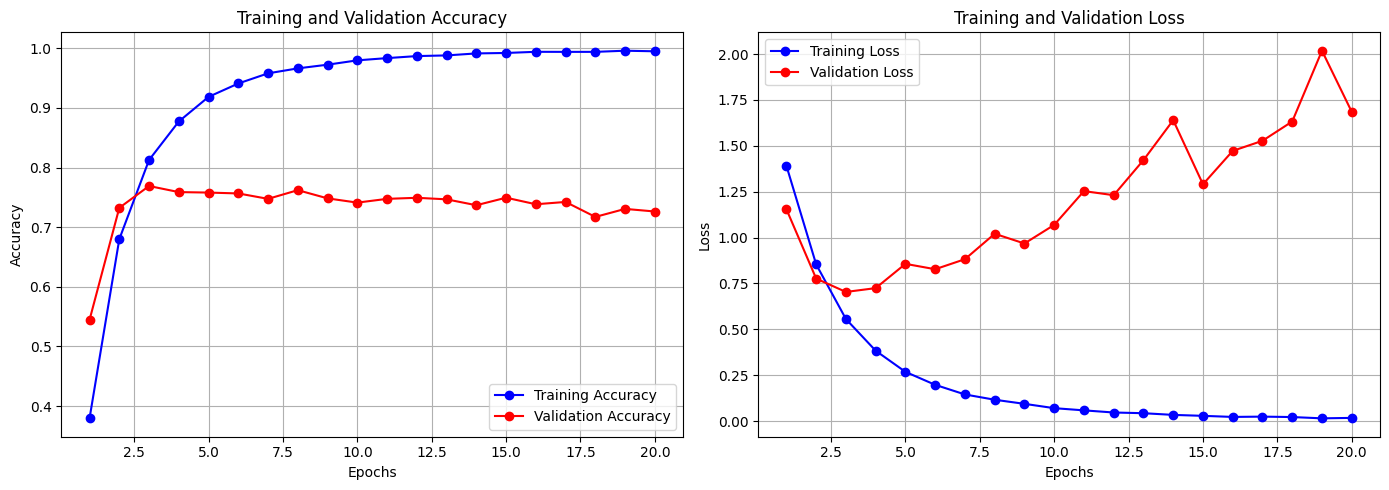

In [35]:
epochs = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], 'b-o', label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], 'r-o', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], 'b-o', label='Training Loss')
plt.plot(epochs, history.history['val_loss'], 'r-o', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()